# `LatinHypercube`, `KorobovLattice`, and `Hammersley`: Three New Low-Discrepancy Samplers

This notebook introduces three new discrete distributions added to QMCPy:

| Sampler | Randomized? | Extensible in `n`? |
|---|---|---|
| `LatinHypercube` | Yes (or centered) | No -- must regenerate when `n` changes |
| `KorobovLattice` | Yes (Cranley-Patterson shift) | No -- `n` must be a tabulated value |
| `Hammersley` | No (fully deterministic) | No -- `n` must be fixed in advance |

For each sampler we cover: the mathematical construction,
a 2D visualization against a relevant baseline already in QMCPy, and a
property specific to that sampler. We close with a shared numerical
integration comparison across all three, against two baselines already
present in the library (`IIDStdUniform` and `Halton`), and a summary
guide for choosing between them.

**Contents**
1. [`LatinHypercube`](#lhs)
2. [`KorobovLattice`](#korobov)
3. [`Hammersley`](#hammersley)
4. [Precision comparison against existing baselines](#comparison)
5. [Summary: which sampler should I use?](#summary)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qmcpy import (
    LatinHypercube, KorobovLattice, Hammersley,
    IIDStdUniform, Halton, Lattice,
)

<a id="lhs"></a>
## 1. `LatinHypercube`

### Construction

Latin Hypercube Sampling (LHS) stratifies every one-dimensional marginal
exactly: splitting $[0,1)$ into $n$ equal strata along *any* single
coordinate axis places exactly one point in each stratum. For a given
dimension, a point's coordinate is

$$X_i = \frac{\pi(i) - U_i}{n}, \qquad i=1,\dots,n,$$

where $\pi$ is an independent random permutation of $1,\dots,n$ and
$U_i \sim \text{Uniform}(0,1)$ i.i.d., drawn independently for every
dimension. Setting `randomize=False` replaces $U_i$ with the constant
$0.5$, placing each point at the center of its stratum instead (the
permutation itself is still drawn randomly -- otherwise every dimension
would place its points on the same diagonal pattern).

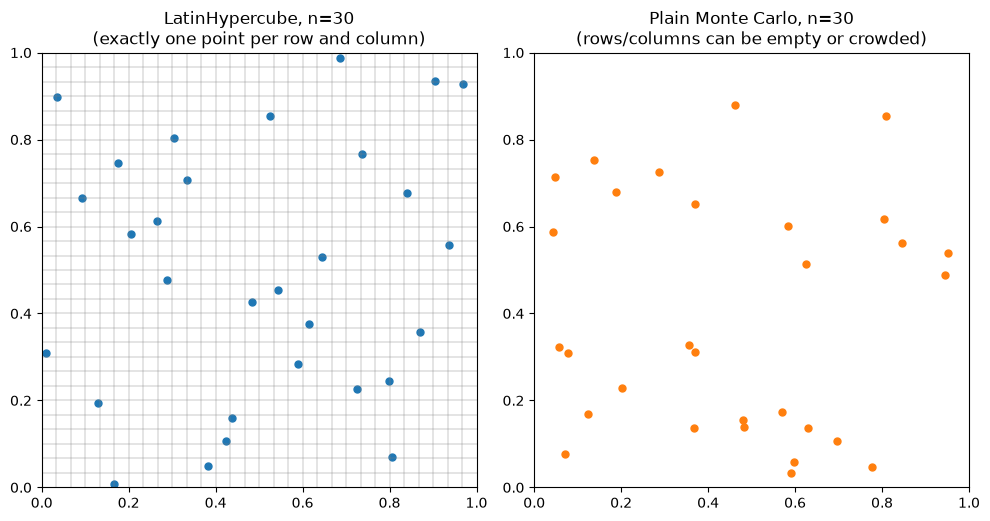

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

pts_lhs = LatinHypercube(dimension=2, replications=None, seed=7)(30)
axes[0].scatter(pts_lhs[:, 0], pts_lhs[:, 1], s=25)
for k in range(1, 30):
    axes[0].axhline(k/30, color="gray", lw=0.3)
    axes[0].axvline(k/30, color="gray", lw=0.3)
axes[0].set_title("LatinHypercube, n=30\n(exactly one point per row and column)")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].set_aspect("equal")

pts_random = IIDStdUniform(dimension=2, seed=7).gen_samples(30)
axes[1].scatter(pts_random[:, 0], pts_random[:, 1], s=25, color="tab:orange")
axes[1].set_title("Plain Monte Carlo, n=30\n(rows/columns can be empty or crowded)")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1); axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

### Strength: additive integrands (Stein, 1987)

Stein (1987) shows that Latin Hypercube Sampling works especially well
when the integrand is close to *additive* -- that is, when it behaves
roughly like a sum of functions that each depend on only one variable,
with little interaction between dimensions. In that case, LHS's
stratification (exactly one point per row and column, in every dimension)
cancels out most of the variance coming from that additive part, so LHS
beats plain Monte Carlo by more than just a better constant -- the *rate*
at which the error shrinks improves too.

We demonstrate this below on $f(x) = \sum_i \sin(2\pi(i+1)x_i)$, a purely
additive function (no interaction at all between dimensions) that
integrates to exactly $0$ over $[0,1]^d$.

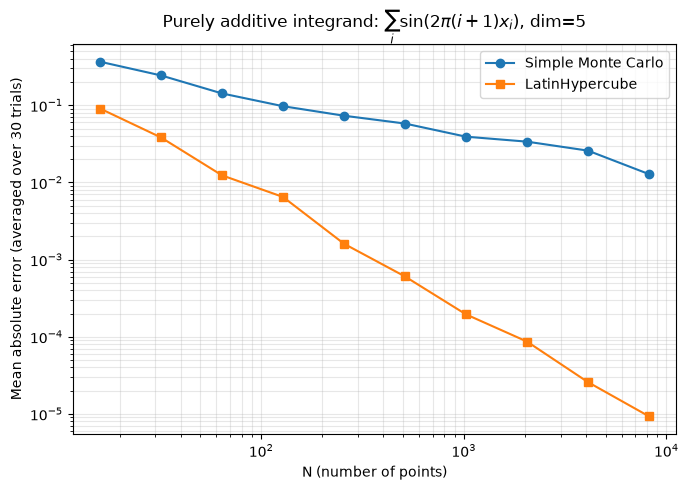

In [9]:
def additive_function(x):
    d = x.shape[1]
    return sum(np.sin(2*np.pi*(i+1)*x[:, i]) for i in range(d))

DIM = 5
TRUE_VALUE = 0.0
N_VALUES = [2**k for k in range(4, 14)]
N_TRIALS = 30  # average over independent seeds for a stable comparison

lhs_errors, mc_errors = [], []
for N in N_VALUES:
    lhs_trial_errors, mc_trial_errors = [], []
    for trial in range(N_TRIALS):
        x_lhs = LatinHypercube(dimension=DIM, replications=None, seed=trial).gen_samples(N, warn=False)
        lhs_trial_errors.append(abs(additive_function(x_lhs).mean() - TRUE_VALUE))

        x_mc = IIDStdUniform(dimension=DIM, seed=1000 + trial).gen_samples(N)
        mc_trial_errors.append(abs(additive_function(x_mc).mean() - TRUE_VALUE))

    lhs_errors.append(np.mean(lhs_trial_errors))
    mc_errors.append(np.mean(mc_trial_errors))

plt.figure(figsize=(7, 5))
plt.loglog(N_VALUES, mc_errors, "o-", label="Simple Monte Carlo")
plt.loglog(N_VALUES, lhs_errors, "s-", label="LatinHypercube")
plt.xlabel("N (number of points)")
plt.ylabel("Mean absolute error (averaged over 30 trials)")
plt.title(r"Purely additive integrand: $\sum_i \sin(2\pi(i+1)x_i)$, dim=5")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The *slope* of the LHS curve is steeper than Monte Carlo's, not just its
constant -- exactly the rate improvement Stein's theorem predicts for an
additive integrand.

<a id="korobov"></a>
## 2. `KorobovLattice`

### Construction

A rank-1 lattice rule with $n$ points and generating vector
$z \in \mathbb{Z}^d$ is

$$P_n(z) = \{(\{kz_1/n\},\dots,\{kz_d/n\}) : k=0,\dots,n-1\}.$$

The **Korobov** construction restricts $z$ to a single integer parameter
$a$: $z(a) = (1, a, a^2, \dots, a^{d-1}) \bmod n$, with $\gcd(a,n)=1$.
Rather than searching for $a$ at construction time (as the general
`Lattice` class does via a component-by-component search), `KorobovLattice`
looks up a precomputed, quality-optimized $a$ for each $(n, d)$ pair,
minimizing the weighted $P_2$ figure of merit (the squared worst-case
integration error in the weighted Korobov space of smoothness 2) with
product weights $\gamma_j = 1/j^2$. This makes construction essentially
free (a table lookup) at the cost of a smaller search space than `Lattice`'s
full CBC search.

Because $a$ is tabulated for specific $(n, d)$ pairs, `n` must be one of
the values in the table, and `n_min` must be $0$.

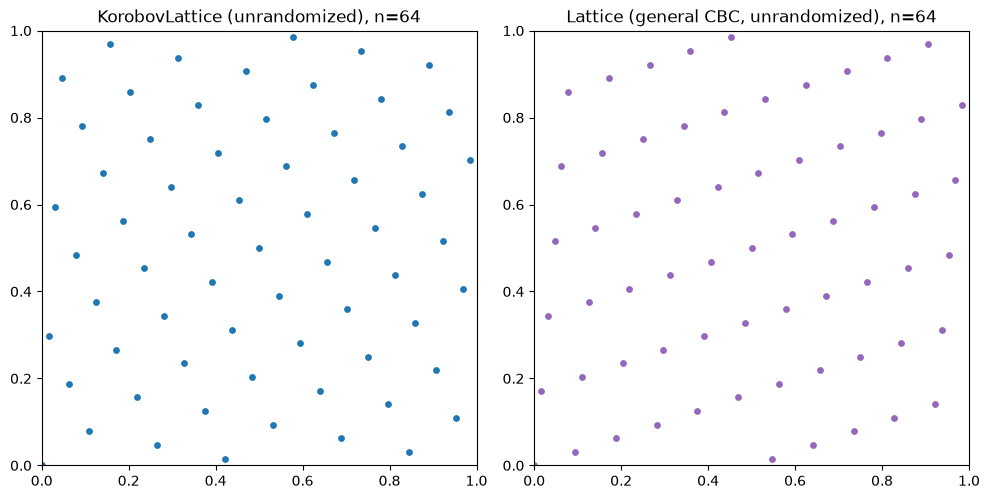

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

pts_korobov = KorobovLattice(dimension=2, randomize="FALSE", seed=7)(64, warn=False)
axes[0].scatter(pts_korobov[:, 0], pts_korobov[:, 1], s=15)
axes[0].set_title("KorobovLattice (unrandomized), n=64")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].set_aspect("equal")

pts_lattice = Lattice(dimension=2, randomize=False)(64, warn=False)
axes[1].scatter(pts_lattice[:, 0], pts_lattice[:, 1], s=15, color="tab:purple")
axes[1].set_title("Lattice (general CBC, unrandomized), n=64")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1); axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

Both are rank-1 lattices, so both show the characteristic regularly
spaced parallel lines. `KorobovLattice`'s single-parameter search space is
smaller than `Lattice`'s full CBC search, but the table lookup is instant
regardless of $n$ or $d$ (within the table's range), whereas `Lattice`
searches for a good vector at construction time.

<a id="hammersley"></a>
## 3. `Hammersley`

### Construction

With $p_1,\dots,p_{d-1}$ the first $d-1$ prime numbers, the Hammersley
point set with $n$ points in $d$ dimensions is

$$t_i = \left(\frac{i}{n},\ \varphi_{p_1}(i),\ \dots,\ \varphi_{p_{d-1}}(i)\right), \qquad i=0,\dots,n-1,$$

where $\varphi_p$ is the radical inverse function in base $p$ -- the same
function underlying `Halton`. Unlike `Halton`, Hammersley is a
**"closed"** point set: $n$ must be fixed in advance, since the $i/n$
coordinate depends on the total number of points. In exchange, the QMC
error bound gains one fewer power of $\log n$ than the corresponding
Halton bound:

$$|I_d(f) - Q_{n,d}(f)| \le C_d\,\frac{(\log n)^{d-1}}{n}\, V(f).$$

C:\Users\samue\QMCSoftware\qmcpy\discrete_distribution\digital_net_any_bases\digital_net_any_bases.py:357: UserWarning: It is more efficient to use DigitalNetB2 instead of DigitalNetAnyBases when all bases are 2
  warnings.warn("It is more efficient to use DigitalNetB2 instead of DigitalNetAnyBases when all bases are 2")


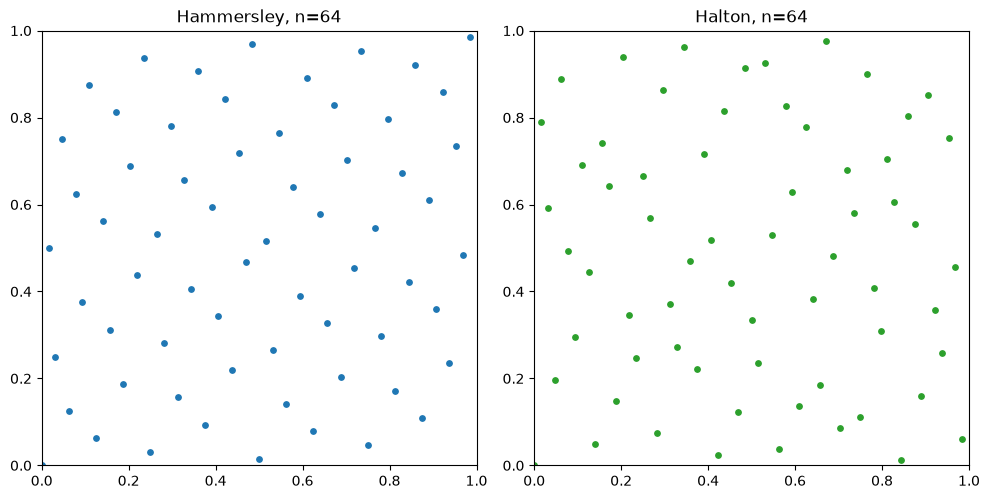

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

pts_hammersley = Hammersley(dimension=2, seed=7)(64, warn=False)
axes[0].scatter(pts_hammersley[:, 0], pts_hammersley[:, 1], s=15)
axes[0].set_title("Hammersley, n=64")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].set_aspect("equal")

pts_halton = Halton(dimension=2, randomize=False)(64, warn=False)
axes[1].scatter(pts_halton[:, 0], pts_halton[:, 1], s=15, color="tab:green")
axes[1].set_title("Halton, n=64")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1); axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

Both cover the square evenly, but Hammersley's first coordinate is the
exact grid $i/n$ rather than a radical-inverse sequence -- visible as the
perfectly regular horizontal spacing.

<a id="comparison"></a>
## 4. Precision comparison against existing baselines

We now compare all three new samplers against two baselines already in
QMCPy -- plain Monte Carlo (`IIDStdUniform`) and `Lattice` -- on a shared
smooth integrand: $f(x) = \prod_i \cos(\pi x_i / 2)$ over $[0,1]^d$, which
integrates to $(2/\pi)^d$.

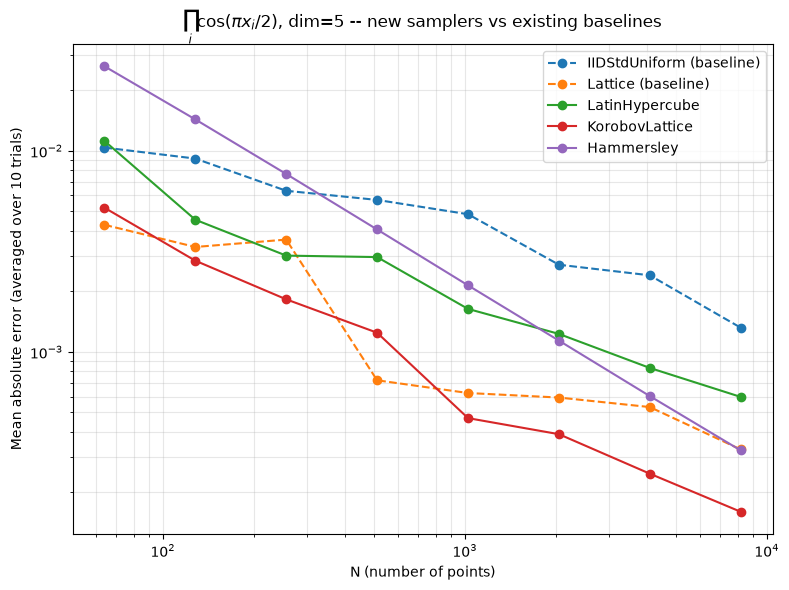

In [22]:
def smooth_integrand(x):
    return np.prod(np.cos(x * (np.pi / 2)), axis=1)

DIM = 5
TRUE_VALUE = (2 / np.pi) ** DIM
N_VALUES = [2**k for k in range(6, 14)]
N_TRIALS = 10

samplers = {
    "IIDStdUniform (baseline)": lambda N, seed: IIDStdUniform(dimension=DIM, seed=seed).gen_samples(N),
    "Lattice (baseline)": lambda N, seed: Lattice(dimension=DIM, seed=seed).gen_samples(N, warn=False),
    "LatinHypercube": lambda N, seed: LatinHypercube(dimension=DIM, replications=None, seed=seed).gen_samples(N, warn=False),
    "KorobovLattice": lambda N, seed: KorobovLattice(dimension=DIM, seed=seed).gen_samples(N),
    "Hammersley": lambda N, seed: Hammersley(dimension=DIM, seed=seed).gen_samples(N, warn=False),
}

errors = {name: [] for name in samplers}
for N in N_VALUES:
    for name, sampler_fn in samplers.items():
        trial_errors = [
            abs(smooth_integrand(sampler_fn(N, trial)).mean() - TRUE_VALUE)
            for trial in range(N_TRIALS)
        ]
        errors[name].append(np.mean(trial_errors))

plt.figure(figsize=(8, 6))
for name, err in errors.items():
    style = "--" if "baseline" in name else "-"
    plt.loglog(N_VALUES, err, style, marker="o", label=name)
plt.xlabel("N (number of points)")
plt.ylabel("Mean absolute error (averaged over 10 trials)")
plt.title(f"$\prod_i \cos(\pi x_i/2)$, dim={DIM} -- new samplers vs existing baselines")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Note: `KorobovLattice` only accepts values of `N` present in its
precomputed table, so this cell may need `N_VALUES` adjusted to match
available table entries -- see the error message raised if an
unavailable `N` is requested for the dimension used here.

<a id="summary"></a>
## 6. Summary: which sampler should I use?

| Sampler | Best suited for | Watch out for |
|---|---|---|
| `LatinHypercube` | Integrands with a strong additive component (Stein's theorem); general-purpose variance reduction when no other structure is known | Not extensible in `n`; loses its stratification advantage on strongly non-additive (highly interacting) integrands |
| `KorobovLattice` | Smooth integrands, when `n` is known in advance and lies in the precomputed table | `n_min` must be 0; `n` must be a tabulated value; smaller search space than the general `Lattice` class |
| `Hammersley` | Deterministic QMC when the sample size is known ahead of time and no randomization is needed | Not extensible in `n`; no randomization support (unlike `Halton`, which can be scrambled) |

**References**

1. M. D. McKay, R. J. Beckman, and W. J. Conover. *A Comparison of Three Methods for Selecting Values of Input Variables in the Analysis of Output from a Computer Code.* Technometrics, 21(2):239-245, 1979.
2. M. Stein. *Large Sample Properties of Simulations Using Latin Hypercube Sampling.* Technometrics, 29(2):143-151, 1987.
3. N. M. Korobov. *The approximate computation of multiple integrals.* Dokl. Akad. Nauk SSSR, 124:1207-1210, 1959.
4. I. H. Sloan and S. Joe. *Lattice Methods for Multiple Integration.* Oxford University Press, 1994.
5. J. Dick, F. Y. Kuo, and I. H. Sloan. *High-dimensional integration: the quasi-Monte Carlo way.* Acta Numerica, 22:133-288, 2013.
6. J. M. Hammersley. *Monte Carlo methods for solving multivariate problems.* Annals of the New York Academy of Sciences, 86(3):844-874, 1960.
